# WSX solenoid — each code generates its own Gaussian

Same solenoid, same geometry and same planes as `../wsx_solenoid_gauss/`. The difference
is where the beam comes from: **neither code reads a particle file.** OPALX builds it
with `DISTRIBUTION, TYPE = GAUSS` and G4BL with `beam gaussian`, from matching
parameters.

So this tests the two *generators* as well as the tracking — but the two codes draw
**different random particles**, so nothing here can be compared per particle. Every
comparison is statistical, and every quantity carries sampling noise. For the strict
per-particle test use `../wsx_solenoid/` (13 particles) or `../wsx_solenoid_gauss/`
(15000 from one shared file).

**The number to keep in mind:** the rms of N samples is itself uncertain by roughly
1/√(2N), which is **0.58 %** at N = 15000. Agreement at that level is success; agreement
at 1e-6 would mean the two codes were somehow not drawing independently.


## Setup


In [1]:
import subprocess, sys
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

HERE = Path.cwd()
ROOT = HERE.parents[3]
sys.path.insert(0, str(ROOT / "runs" / "processing"))

MU_MASS     = 0.1056583755         # GeV
MU_MASS_MEV = MU_MASS * 1e3        # mass in MeV/c^2; numerically m*c in MeV/c
P0          = 0.028                # GeV/c
BG0         = P0 / MU_MASS
GAMMA0      = np.sqrt(1.0 + BG0**2)
BETA0       = BG0 / GAMMA0
BRHO        = P0 / 0.299792458     # T*m   (0.299792458 = 1e-9*c; charge = 1e)

# --- what BOTH inputs were asked for (they must agree with the two input files) ---
NPART = 15000
SIG   = dict(x=10.0, y=3.0, xp=2.0, yp=2.0, z=1.0)   # mm and mrad
CUTOFF_SIGMA = 10.0     # OPALX CUTOFF*; g4bl does not truncate at all

# relative uncertainty on an rms from N samples
RMS_TOL = 1.0 / np.sqrt(2 * NPART)

PLANES_MM = [150, 600, 1050, 1500, 1950, 2400, 2850, 3450]
OPALX_MON = [f"MON_{i+1:02d}_Z{z}.h5" for i, z in enumerate(PLANES_MM)]
G4BL_NT   = [f"Z{z}.txt" for z in PLANES_MM]

OPALX_BLUE = "#1f5fd1"
G4BL_RED   = "#c1432d"
ALPHA      = 0.18

print(f"beta*gamma {BG0:.7f}   beta {BETA0:.7f}   Brho {BRHO:.6f} T*m")
print(f"requested: sigma_x {SIG['x']} mm, sigma_y {SIG['y']} mm, "
      f"sigma_x' {SIG['xp']} mrad, sigma_z {SIG['z']} mm, monoenergetic 28 MeV/c")
print(f"N = {NPART}  ->  expected rms scatter 1/sqrt(2N) = {RMS_TOL*100:.2f} %")


beta*gamma 0.2650050   beta 0.2561628   Brho 0.093398 T*m
requested: sigma_x 10.0 mm, sigma_y 3.0 mm, sigma_x' 2.0 mrad, sigma_z 1.0 mm, monoenergetic 28 MeV/c
N = 15000  ->  expected rms scatter 1/sqrt(2N) = 0.58 %


## The setup

Identical geometry to the other cases; `z` here is g4bl's global z, which equals OPALX
path length `s` times 1000.


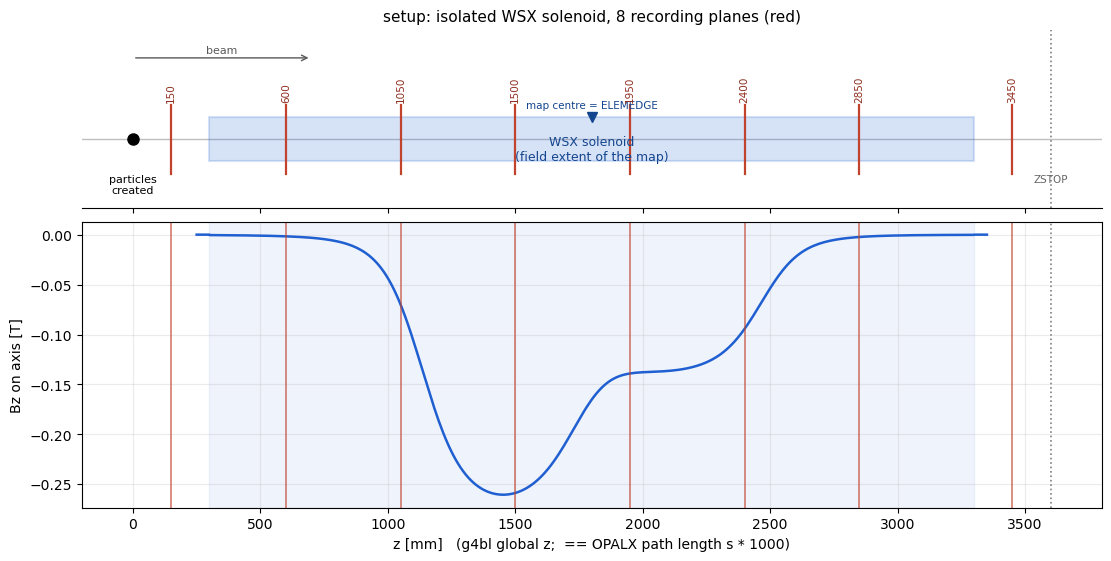

field      300 .. 3300 mm   (map centre 1800 mm)
planes     [150, 600, 1050, 1500, 1950, 2400, 2850, 3450]
planes in field-free drift: [150, 3450]


In [2]:
# --- the setup being tested -------------------------------------------------
# Geometry is fixed by the two input files and is the same in both codes:
#   g4bl  `place MAG z=1800`, map local z -1500..+1500  -> field at 300..3300 mm
#   opalx `SOLENOID ELEMEDGE = 1.800`                   -> field at 0.300..3.300 m
# ELEMEDGE is the lab position of the map CENTRE, not of the field start.
MAP_CENTRE_MM = 1800
FIELD_MM      = (300, 3300)
ZSTOP_MM      = 3600
PLANES = PLANES_MM if "PLANES_MM" in dir() else [Z_IN_MM, Z_OUT_MM]

fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True,
                       gridspec_kw=dict(height_ratios=[1, 1.6]),
                       constrained_layout=True)

# ---- schematic ----
a = ax[0]
a.axhline(0, color="0.75", lw=1, zorder=0)
a.add_patch(plt.Rectangle((FIELD_MM[0], -0.35), FIELD_MM[1] - FIELD_MM[0], 0.7,
                          facecolor="#1f5fd1", alpha=0.18, edgecolor="#1f5fd1", lw=1.5))
a.text(np.mean(FIELD_MM), -0.15, "WSX solenoid\n(field extent of the map)",
       ha="center", va="center", fontsize=9, color="#14458f")
a.plot([MAP_CENTRE_MM], [0.35], "v", ms=7, color="#14458f")
a.annotate("map centre = ELEMEDGE", (MAP_CENTRE_MM, 0.50), ha="center", fontsize=7.5,
           color="#14458f")

a.plot([0], [0], "o", ms=8, color="black", zorder=5)
a.annotate("particles\ncreated", (0, -0.55), ha="center", va="top", fontsize=8)
a.annotate("", xy=(700, 1.30), xytext=(0, 1.30),
           arrowprops=dict(arrowstyle="->", color="0.35"))
a.text(350, 1.38, "beam", ha="center", fontsize=8, color="0.35")

for z in PLANES:
    a.plot([z, z], [-0.55, 0.55], "-", color="#c1432d", lw=1.6)
    a.annotate(f"{z}", (z, 0.62), ha="center", fontsize=7.5, rotation=90,
               color="#8f2f1f")
a.axvline(ZSTOP_MM, color="0.5", ls=":", lw=1.2)
a.annotate("ZSTOP", (ZSTOP_MM, -0.55), ha="center", va="top", fontsize=7.5, color="0.4")

a.set_ylim(-1.1, 1.75); a.set_yticks([])
a.set_title(f"setup: isolated WSX solenoid, {len(PLANES)} recording plane"
            f"{'s' if len(PLANES) > 1 else ''} (red)", fontsize=11)
for side in ("left", "right", "top"):
    a.spines[side].set_visible(False)

# ---- on-axis field, if g4bl has already been run ----
b = ax[1]
axis_file = Path("g4bl_axis.txt")
if axis_file.is_file():
    d = np.loadtxt(axis_file, comments="#", ndmin=2)
    b.plot(d[:, 2], d[:, 6], "-", color="#1f5fd1", lw=1.8)
    b.set_ylabel("Bz on axis [T]")
else:
    b.text(0.5, 0.5, "run g4bl to see the on-axis field here",
           transform=b.transAxes, ha="center", va="center", color="0.5", fontsize=9)
    b.set_yticks([])
b.axvspan(*FIELD_MM, color="#1f5fd1", alpha=0.07)
for z in PLANES:
    b.axvline(z, color="#c1432d", lw=1.2, alpha=0.7)
b.axvline(ZSTOP_MM, color="0.5", ls=":", lw=1.2)
b.grid(alpha=0.25)
b.set_xlabel("z [mm]   (g4bl global z;  == OPALX path length s * 1000)")
b.set_xlim(-200, ZSTOP_MM + 200)
plt.show()

print(f"field      {FIELD_MM[0]} .. {FIELD_MM[1]} mm   (map centre {MAP_CENTRE_MM} mm)")
print(f"planes     {PLANES}")
print(f"planes in field-free drift: "
      f"{[z for z in PLANES if z < FIELD_MM[0] or z > FIELD_MM[1]]}")


## How the two beams are defined

No particle files. The parameters have to be translated by hand, and three things do not
map one-to-one:

| | G4BL `beam gaussian` | OPALX `TYPE = GAUSS` |
|---|---|---|
| transverse size | `sigmaX` [mm] | `SIGMAX` [m] |
| divergence | `sigmaXp` — a **slope**, dx/dz | `SIGMAPX` — in **βγ**, so `slope × βγ₀` |
| momentum | `meanMomentum` [MeV/c], `sigmaP=0` | `PC` on the **BEAM** |
| tails | `RandGauss::shoot()`, no cutoff; `maxR` defaults to 1 km | `CUTOFF*` **default 3.0**, hard-truncated |

Two of these are easy to get wrong:

- **`PC` is required here and forbidden with `FROMFILE`.** `TrackRun` sets the
  distribution's average pz from the BEAM momentum. Leave it out and the Gaussian is
  built around pz = 0.
- **OPALX truncates by default.** `Gaussian.cpp` samples by inverse transform over
  `[-CUTOFF·σ, +CUTOFF·σ]`, so at the default 3σ it puts *exactly zero* particles in the
  tails where G4BL puts ~0.27 % per axis — about 40 of 15000. The input widens `CUTOFF*`
  to 10 so the two are comparable; the check below confirms neither beam is clipped.


## Run both codes


In [ ]:
G4BL_APP = Path("/Users/rammann/Code/G4BL/G4beamline-3.08.app")
OPALX_CANDIDATES = [ROOT / "build/src/opalx",
                    ROOT / "opalx/build_serial/src/opalx",
                    ROOT / "opalx/build/src/opalx"]


def run_g4bl():
    for f in G4BL_NT + ["g4bl_axis.txt", "g4bl.log"]:
        Path(f).unlink(missing_ok=True)
    cmd = (f'source "{G4BL_APP}/Contents/root/bin/thisroot.sh" && '
           f'"{G4BL_APP}/Contents/MacOS/g4bl" wsx_solenoid_gaussdist.g4bl')
    r = subprocess.run(["bash", "-c", cmd], capture_output=True, text=True)
    Path("g4bl.log").write_text(r.stdout + r.stderr)
    print("g4bl rc =", r.returncode)
    return r.returncode


def run_opalx():
    # NOTE: needs the OPALX build with the .g4blmap reader and the solenoid ZREVERSE
    # attribute. On a build without them this fails with
    #   unknown attribute "ZREVERSE"   /   Couldn't determine type of fieldmap
    opalx = next((c for c in OPALX_CANDIDATES if c.is_file()), None)
    if opalx is None:
        raise FileNotFoundError(f"no opalx binary under {ROOT}")
    for f in OPALX_MON + ["wsx_solenoid_gaussdist.h5", "wsx_solenoid_gaussdist.stat"]:
        Path(f).unlink(missing_ok=True)
    r = subprocess.run(["mpirun", "-n", "1", str(opalx),
                        "wsx_solenoid_gaussdist.in", "--info", "1"],
                       capture_output=True, text=True)
    Path("run.log").write_text(r.stdout + r.stderr)
    print("opalx rc =", r.returncode)
    if r.returncode:
        print("  last error:", [l for l in r.stdout.splitlines() if "Error>" in l][-1:])
    return r.returncode


run_g4bl()
run_opalx()


## Readers


In [4]:
def read_g4bl(path):
    # #BLTrackFile: mm, MeV/c, ns. -> x,y [mm], xp,yp [mrad]
    d = np.loadtxt(path, comments="#", ndmin=2)
    px, py, pz = d[:, 3], d[:, 4], d[:, 5]
    return dict(x=d[:, 0], y=d[:, 1], xp=px / pz * 1e3, yp=py / pz * 1e3, n=len(d))


def read_opalx(path):
    # MONITOR .h5: m, beta*gamma. Several Step#N groups -> concatenate.
    keys = ("x", "y", "px", "py", "pz")
    out = {k: [] for k in keys}
    with h5py.File(path, "r") as f:
        for gname in sorted(f, key=lambda s: int(s.split("#")[1])):
            g = f[gname]
            if len(g["x"]):
                for k in keys:
                    out[k].append(np.asarray(g[k]))
    out = {k: np.concatenate(v) for k, v in out.items()}
    return dict(x=out["x"] * 1e3, y=out["y"] * 1e3,
                xp=out["px"] / out["pz"] * 1e3, yp=out["py"] / out["pz"] * 1e3,
                n=len(out["x"]))


def ellipse_tilt_deg(x, y):
    c = np.cov(x, y)
    return np.degrees(0.5 * np.arctan2(2 * c[0, 1], c[0, 0] - c[1, 1]))


def emittance(u, up):
    # rms geometric emittance, mm mrad
    u, up = u - u.mean(), up - up.mean()
    return float(np.sqrt(max(0.0, np.mean(u*u) * np.mean(up*up) - np.mean(u*up)**2)))


G = [read_g4bl(f) for f in G4BL_NT]
O = [read_opalx(f) for f in OPALX_MON]
for z, gg, oo in zip(PLANES_MM, G, O):
    print(f"  z = {z:5d} mm   G4BL N = {gg['n']:5d}   OPALX N = {oo['n']:5d}")


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'MON_01_Z150.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

## Did either generator clip the tails?

The one check that is *not* statistical. G4BL never truncates; OPALX truncates at
`CUTOFF·σ`. If `CUTOFF` were left at its default 3, the OPALX column below would read
3.00 and the G4BL column ~4 — that alone would explain any tail disagreement, so it is
worth ruling out before reading anything else.


In [ ]:
print(f"{'':>6} {'max|x|/sigma':>14} {'max|y|/sigma':>14} "
      f"{'max|x-prime|/sig':>17} {'max|y-prime|/sig':>17}")
print("-" * 74)
for tag, d in (("OPALX", O[0]), ("G4BL", G[0])):
    vals = [np.abs(d[k]).max() / np.std(d[k]) for k in ("x", "y", "xp", "yp")]
    print(f"{tag:>6} " + "".join(f"{v:>14.2f}  " for v in vals[:2])
          + "".join(f"{v:>17.2f}" for v in vals[2:]))
print(f"\nOPALX CUTOFF* is set to {CUTOFF_SIGMA:g} in the input; a value of ~{CUTOFF_SIGMA:g}")
print("above would mean the beam is being clipped. ~4 sigma is what an untruncated")
print(f"Gaussian of {NPART} samples reaches by chance.")


## Statistics at every plane

`d/tol` is the difference in units of the expected sampling scatter 1/√(2N) = 0.58 %.
Values around 1 are agreement; values of 3 or more are worth looking at.


In [ ]:
print(f"{'z [mm]':>7} {'rms x  O / G':>22} {'d/tol':>7} {'rms y  O / G':>22} {'d/tol':>7} "
      f"{'emit x  O / G':>20} {'tilt O / G [deg]':>21}")
print("-" * 112)
worst = 0.0
for i, z in enumerate(PLANES_MM):
    o, g = O[i], G[i]
    row = []
    for k in ("x", "y"):
        so, sg = np.std(o[k]), np.std(g[k])
        rel = abs(so - sg) / (0.5 * (so + sg)) / RMS_TOL
        worst = max(worst, rel)
        row.append((so, sg, rel))
    eo, eg = emittance(o["x"], o["xp"]), emittance(g["x"], g["xp"])
    to, tg = ellipse_tilt_deg(o["x"], o["y"]), ellipse_tilt_deg(g["x"], g["y"])
    print(f"{z:>7} {row[0][0]:>10.4f} /{row[0][1]:>10.4f} {row[0][2]:>7.2f} "
          f"{row[1][0]:>10.4f} /{row[1][1]:>10.4f} {row[1][2]:>7.2f} "
          f"{eo:>9.4f} /{eg:>9.4f} {to:>+10.3f} /{tg:>+9.3f}")
print(f"\nexpected rms scatter 1/sqrt(2N) = {RMS_TOL*100:.2f} %   "
      f"worst |d| / tol over all planes = {worst:.2f}")


## Are the projected distributions the same?

With different particles, "do these agree" is a two-sample question, so use a two-sample
Kolmogorov–Smirnov test rather than eyeballing the histograms. A p-value that is not
small means the two samples are consistent with being drawn from the same distribution.
p below ~0.01 at several planes at once would be a real signal.


In [ ]:
print(f"{'z [mm]':>7} " + "".join(f"{'KS p (' + k + ')':>16}" for k in ("x", "y", "x'", "y'")))
print("-" * 71)
for i, z in enumerate(PLANES_MM):
    ps = [ks_2samp(O[i][k], G[i][k]).pvalue for k in ("x", "y", "xp", "yp")]
    flag = "   <- low" if min(ps) < 0.01 else ""
    print(f"{z:>7} " + "".join(f"{p:>16.3f}" for p in ps) + flag)
print("\np is uniform on [0,1] when the two samples really do come from the same")
print("distribution, so isolated small values are expected; a column of them is not.")


## Monitor plots

Same panel style as the other cases — but remember these are **different particles**, so
the two rows will not overlay point for point, only in shape and extent.

Every position axis shares one range and both angle axes another; the x–y panel is set to
equal aspect so the tilt reads true.


In [ ]:
def plot_pair(z_mm, o, g, outdir=Path("monitor_plots"), pm=None, am=None):
    outdir.mkdir(exist_ok=True)
    if pm is None:
        pm = 1.05 * max(np.abs(d[k]).max() for d in (o, g) for k in ("x", "y"))
    if am is None:
        am = 1.05 * max(np.abs(d[k]).max() for d in (o, g) for k in ("xp", "yp"))
    panels = [("x", "xp", "x [mm]", "x' [mrad]", "x - x'", pm, am),
              ("y", "yp", "y [mm]", "y' [mrad]", "y - y'", pm, am),
              ("x", "y",  "x [mm]", "y [mm]",    "x - y",  pm, pm)]

    fig, ax = plt.subplots(2, 3, figsize=(13, 8.6), constrained_layout=True)
    for row, (d, colour, tag) in enumerate([(o, OPALX_BLUE, "OPALX"),
                                            (g, G4BL_RED, "G4BL")]):
        for col, (ku, kv, xl, yl, tt, ulim, vlim) in enumerate(panels):
            a = ax[row, col]
            a.scatter(d[ku], d[kv], s=2, alpha=ALPHA, edgecolors="none", color=colour)
            a.set_xlabel(xl); a.set_ylabel(yl)
            a.set_title(f"{tt}   [{tag}, N = {d['n']}]", fontsize=10)
            a.grid(True, alpha=0.25)
            a.set_xlim(-ulim, ulim); a.set_ylim(-vlim, vlim)
            if ku == "x" and kv == "y":
                a.set_aspect("equal", adjustable="box")

    tilt_o, tilt_g = ellipse_tilt_deg(o["x"], o["y"]), ellipse_tilt_deg(g["x"], g["y"])
    fig.suptitle(f"z = {z_mm} mm  (s = {z_mm/1e3:.3f} m)   "
                 f"x-y tilt: OPALX {tilt_o:+.2f}deg, G4BL {tilt_g:+.2f}deg", fontsize=12)
    fig.savefig(outdir / f"Z{z_mm}.png", dpi=110)
    return fig


for z, oo, gg in zip(PLANES_MM, O, G):
    plot_pair(z, oo, gg)
plt.show()


## Projections at the first and last plane

One row per plane, one column per coordinate. Bin edges are shared between the codes and
between the rows; position columns share one range and angle columns another. G4BL is
dashed so the two are told apart by more than colour.

Here the two curves are *not* expected to lie on top of each other bin for bin — they are
different samples. What should match is the shape and the width, to about √N per bin.


In [ ]:
def projections(planes=(0, -1), nbins=80, outdir=Path("monitor_plots")):
    outdir.mkdir(exist_ok=True)
    idx  = [range(len(PLANES_MM))[i] for i in planes]
    cols = [("x", "x [mm]"), ("xp", "x' [mrad]"),
            ("y", "y [mm]"), ("yp", "y' [mrad]")]

    pm = 1.05 * max(np.abs(d[k]).max() for i in idx for d in (O[i], G[i])
                    for k in ("x", "y"))
    am = 1.05 * max(np.abs(d[k]).max() for i in idx for d in (O[i], G[i])
                    for k in ("xp", "yp"))
    edges = {"x": np.linspace(-pm, pm, nbins + 1), "y": np.linspace(-pm, pm, nbins + 1),
             "xp": np.linspace(-am, am, nbins + 1), "yp": np.linspace(-am, am, nbins + 1)}

    fig, ax = plt.subplots(len(idx), 4, figsize=(15, 3.4 * len(idx)),
                           constrained_layout=True)
    ax = np.atleast_2d(ax)
    rows = []
    for r, i in enumerate(idx):
        o, g = O[i], G[i]
        for c, (k, xl) in enumerate(cols):
            a = ax[r, c]
            a.hist(o[k], bins=edges[k], histtype="step", lw=1.8, color=OPALX_BLUE,
                   label="OPALX")
            a.hist(g[k], bins=edges[k], histtype="step", lw=1.5, ls="--", color=G4BL_RED,
                   label="G4BL")
            a.set_xlabel(xl); a.grid(alpha=0.25)
            if c == 0:
                a.set_ylabel(f"z = {PLANES_MM[i]} mm\nparticles / bin")
            if r == 0 and c == 0:
                a.legend(fontsize=8)
            a.set_title(f"rms  {np.std(o[k]):.3f} / {np.std(g[k]):.3f}", fontsize=9)
            rows.append((PLANES_MM[i], k, np.mean(o[k]), np.mean(g[k]),
                         np.std(o[k]), np.std(g[k])))
    fig.suptitle("projections at the first and last plane   "
                 "(titles: rms OPALX / G4BL)", fontsize=12)
    fig.savefig(outdir / "projections.png", dpi=110)

    print(f"{'z [mm]':>7} {'coord':>6} {'mean OPALX':>12} {'mean G4BL':>12} "
          f"{'rms OPALX':>11} {'rms G4BL':>11} {'d(rms)/tol':>11}")
    print("-" * 78)
    for z, k, mo, mg, so, sg in rows:
        rel = abs(so - sg) / (0.5 * (so + sg)) / RMS_TOL
        print(f"{z:>7} {k:>6} {mo:>+12.5f} {mg:>+12.5f} {so:>11.5f} {sg:>11.5f} "
              f"{rel:>11.2f}")
    return fig


projections()
plt.show()


## Rotation and sizes along the line

As in the other cases: the measured x–y ellipse tilt against the cumulative Larmor angle
from the field alone. The field prediction is independent of both codes.


In [ ]:
d = np.loadtxt("g4bl_axis.txt", comments="#", ndmin=2)
z_ax, bz_ax = d[:, 2], d[:, 6]
theta_cum = np.concatenate([[0.0], np.cumsum(
    0.5 * (bz_ax[1:] + bz_ax[:-1]) * np.diff(z_ax * 1e-3))]) / (2 * BRHO)
rot_pred = -np.degrees(theta_cum)      # lab beam turns by -theta_L; see ../wsx_solenoid_gauss

s_mm   = np.array(PLANES_MM, dtype=float)
tilt_o = np.array([ellipse_tilt_deg(o["x"], o["y"]) for o in O])
tilt_g = np.array([ellipse_tilt_deg(g["x"], g["y"]) for g in G])
aspect = np.array([max(np.std(o["x"]), np.std(o["y"])) /
                   min(np.std(o["x"]), np.std(o["y"])) for o in O])

fig, ax = plt.subplots(3, 1, figsize=(9, 10), sharex=True, constrained_layout=True)
ax[0].plot(z_ax, rot_pred, "-", color="0.4",
           label=r"$-\int B_z\,ds\,/\,2B\rho$  (field only, no tracking)")
ax[0].plot(s_mm, tilt_o, "o", color=OPALX_BLUE, label="OPALX x-y tilt")
ax[0].plot(s_mm, tilt_g, "x", ms=9, mew=2, color=G4BL_RED, label="G4BL x-y tilt")
round_ = aspect < 1.15
if round_.any():
    ax[0].plot(s_mm[round_], tilt_o[round_], "o", ms=14, mfc="none", mec="0.2",
               label="beam nearly round -> tilt ill-defined")
ax[0].set_ylabel("rotation [deg]"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[0].set_title("Larmor rotation: measured ellipse tilt vs the field integral")

for d_, colour, tag, mk in [(O, OPALX_BLUE, "OPALX", "o"), (G, G4BL_RED, "G4BL", "x")]:
    ax[1].plot(s_mm, [np.std(v["x"]) for v in d_], mk + "-", color=colour, label=f"rms x {tag}")
    ax[1].plot(s_mm, [np.std(v["y"]) for v in d_], mk + "--", color=colour, label=f"rms y {tag}")
ax[1].set_ylabel("rms size [mm]"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

ax[2].plot(z_ax, bz_ax, "-", color="0.4")
ax[2].set_ylabel("Bz on axis [T]"); ax[2].set_xlabel("z [mm]  (== s * 1000)")
ax[2].grid(alpha=.3)
plt.show()
